In [1]:
import pandas as pd
import os

BASE = os.path.join(os.getcwd(), "..")  # project root
shipment = pd.read_csv(os.path.join(BASE, "Data", "raw", "shipments.csv"))


In [2]:
#checking duplicates
dup_count = int(shipment.duplicated(subset="shipment_id").sum())
#checking nulls
missing_val = shipment.isna().sum()
#Number of sellers
total_shipping = shipment["shipment_id"].nunique()

#checking the consistency of category and subcategory

uni_carrier = list(shipment["carrier"].unique())

uni_delivary_stat = list(shipment["delivery_status"].unique())

#checking dtype
shipment.dtypes


shipment_id            str
order_id               str
carrier                str
shipped_at             str
delivered_at           str
ship_from_city         str
ship_to_city           str
shipping_cost      float64
delivery_status        str
dtype: object

In [3]:
shipment["shipped_date"] = shipment["shipped_at"].str.split(" ",expand=True)[0]
shipment["delivered_date"] = shipment["delivered_at"].str.split(" ",expand=True)[0]
shipment["shipped_date"] = pd.to_datetime(shipment["shipped_date"])
shipment["delivered_date"] = pd.to_datetime(shipment["delivered_date"])



In [4]:
shipment["shipped_at"] = pd.to_datetime(shipment["shipped_at"])
shipment["delivered_at"] = pd.to_datetime(shipment["delivered_at"])

shipment["diff_hours"] = ((shipment["delivered_at"] - shipment["shipped_at"]).dt.total_seconds() / 3600).round(2)


In [5]:
shipment["route_covered"] = shipment["ship_from_city"]+"_"+shipment["ship_to_city"]

In [6]:
shipment.dtypes

shipment_id                   str
order_id                      str
carrier                       str
shipped_at         datetime64[us]
delivered_at       datetime64[us]
ship_from_city                str
ship_to_city                  str
shipping_cost             float64
delivery_status               str
shipped_date       datetime64[us]
delivered_date     datetime64[us]
diff_hours                float64
route_covered                 str
dtype: object

In [ ]:
# 1. What is the delivery status distribution by carrier?

# Which carrier has the most OnTime vs Late deliveries?
# Core problem statement — on-time delivery rate declining


In [24]:
carrier_status = (shipment.groupby(["carrier", "delivery_status"])["shipment_id"]
                  .count()
                  .unstack(fill_value=0))
carrier_status["total"] = carrier_status.sum(axis=1)


In [25]:
carrier_status

delivery_status,InTransit,Late_1_2d,Late_3_5d,Late_5p,Lost,OnTime,total
carrier,,,,,,,
BlueDart,1165,5522,114,0,119,14986,21906
Delhivery,1621,7701,1515,23,125,18554,29539
Ekart,1170,5866,795,4,107,13898,21840
InHouse,1087,1299,0,0,79,16244,18709


In [ ]:
for col in ["OnTime", "Late_1_2d", "Late_3_5d", "Late_5p", "Lost","InTransit"]:
    if col in carrier_status.columns:
        carrier_status[f"{col}_pct"] = ((carrier_status[col] / carrier_status["total"]) * 100).round(2)

carrier_status.sort_values("OnTime_pct", ascending=False)

delivery_status,InTransit,Late_1_2d,Late_3_5d,Late_5p,Lost,OnTime,total,OnTime_pct,Late_1_2d_pct,Late_3_5d_pct,Late_5p_pct,Lost_pct,InTransit_pct
carrier,,,,,,,,,,,,,
InHouse,1087,1299,0,0,79,16244,18709,86.82,6.94,0.00,0.00,0.42,5.81
BlueDart,1165,5522,114,0,119,14986,21906,68.41,25.21,0.52,0.00,0.54,5.32
Ekart,1170,5866,795,4,107,13898,21840,63.64,26.86,3.64,0.02,0.49,5.36
Delhivery,1621,7701,1515,23,125,18554,29539,62.81,26.07,5.13,0.08,0.42,5.49


In [28]:
#Average delivary time by carrier
# Which carrier is fastest vs slowest?
# Are some carriers consistently breaching the 2 day (48 hour) promise?
shipment.groupby("carrier")["diff_hours"].agg(["mean", "min", "max", "median"]).round(2)

,mean,min,max,median
carrier,,,,
BlueDart,35.98,12.0,121.04,33.16
Delhivery,42.43,12.0,188.47,34.75
Ekart,40.65,12.0,166.02,34.58
InHouse,22.72,7.2,71.99,20.07


In [38]:
#3. Which routes (ship_from → ship_to) have the most delays?

# Which lanes are problematic?
# Is it a specific city pair causing delays?
val_route = shipment.groupby(["route_covered", "delivery_status"])["shipment_id"].count().unstack(fill_value=0)

In [43]:
val_route = (shipment.groupby(["route_covered", "delivery_status"])["shipment_id"]
             .count()
             .unstack(fill_value=0))

# Total and percentages
val_route["total"]     = val_route.sum(axis=1)
val_route["late_pct"]  = ((val_route.get("Late_1_2d", 0) + 
                            val_route.get("Late_3_5d", 0) + 
                            val_route.get("Late_5p", 0)) / 
                            val_route["total"] * 100).round(2)
val_route["ontime_pct"] = (val_route["OnTime"] / val_route["total"] * 100).round(2)

# Top 10 most delayed routes
print("Top 10 Most Delayed Routes")
print(val_route[["total", "OnTime", "late_pct", "ontime_pct"]]
      .sort_values("late_pct", ascending=False)
      .head(10))

# Top 10 most ontime routes
print("\nTop 10 Most OnTime Routes")
print(val_route[["total", "OnTime", "late_pct", "ontime_pct"]]
      .sort_values("ontime_pct", ascending=False)
      .head(10))

# Top 3 most frequent routes
print("\nTop 3 Most Frequent Routes")
print(val_route[["total", "late_pct", "ontime_pct"]]
      .sort_values("total", ascending=False)
      .head(3))

Top 10 Most Delayed Routes
delivery_status    total  OnTime  late_pct  ontime_pct
route_covered                                         
Chennai_Jaipur       277     112     52.71       40.43
Kolkata_Lucknow      301     131     51.16       43.52
Delhi_Jaipur         616     271     50.97       43.99
Jaipur_Jaipur        185      85     50.81       45.95
Bangalore_Jaipur     494     225     49.60       45.55
Ahmedabad_Lucknow    150      70     49.33       46.67
Delhi_Lucknow        607     276     49.09       45.47
Pune_Jaipur          326     150     48.77       46.01
Bangalore_Lucknow    466     206     48.50       44.21
Kolkata_Jaipur       327     147     48.32       44.95

Top 10 Most OnTime Routes
delivery_status       total  OnTime  late_pct  ontime_pct
route_covered                                            
Kochi_Delhi             425     349     13.41       82.12
Chandigarh_Bangalore    385     302     16.62       78.44
Lucknow_Mumbai          565     443     17.35       78

In [47]:
#4. What is the shipping cost by carrier and route?
# Are expensive carriers also the most delayed?
# Are we paying more for worse service?
shipment.groupby("carrier")["shipping_cost"].agg(["mean", "min","max","median"]).round(2)

,mean,min,max,median
carrier,,,,
BlueDart,108.63,36.02,167.53,110.00
Delhivery,91.04,30.01,139.93,92.36
Ekart,90.86,30.02,139.73,92.03
InHouse,62.21,21.01,97.53,63.44


In [48]:
#5. How has on-time delivery rate trended over time?
# Is the delay problem getting worse month over month?
# When did the decline start?
shipment["shipped_year"]  = shipment["shipped_date"].dt.year
shipment["shipped_month"] = shipment["shipped_date"].dt.month
shipment.groupby(["shipped_year", "shipped_month", "delivery_status"])["shipment_id"].count().unstack(fill_value=0)

delivery_status             InTransit  Late_1_2d  Late_3_5d  Late_5p  Lost  \
shipped_year shipped_month                                                   
2024         7                    276        844        113        0    22   
             8                    286        869        108        1    21   
             9                    277        850        138        1    26   
             10                   272       2168        237        7    29   
             11                   299       2093        211        3    28   
             12                   305        881        129        0    26   
2025         1                    286        867         91        1    27   
             2                    281        770        107        0    19   
             3                    266        870        119        1    35   
             4                    271        831         93        3    20   
             5                    279        854        115        1    31   
             6                    292        862        112        0    19   
             7                    277        883        112        1    18   
             8                    293        883        101        1    17   
             9                    271        805        111        1    22   
             10                   280       2156        211        3    28   
             11                   263       2074        208        3    27   
             12                   269        828        108        0    15   

delivery_status             OnTime  
shipped_year shipped_month          
2024         7                3884  
             8                3824  
             9                3838  
             10               2572  
             11               2459  
             12               3903  
2025         1                3902  
             2                3583  
             3                3902  
             4                3853  
             5                3796  
             6                3749  
             7                3840  
             8                3949  
             9                3750  
             10               2602  
             11               2470  
             12               3806

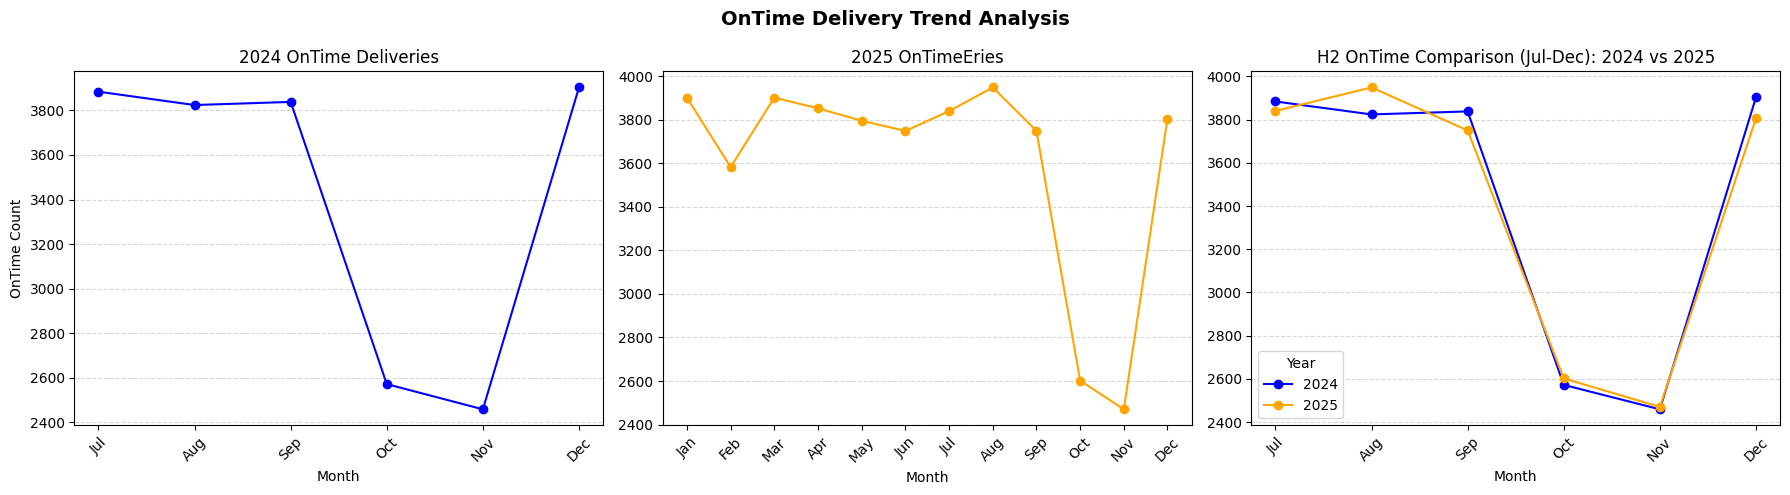

In [50]:
# Prepare data
trend = shipment.groupby(["shipped_year", "shipped_month", "delivery_status"])["shipment_id"]\
                 .count().unstack(fill_value=0).reset_index()

month_names = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
               7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
trend["month_name"] = trend["shipped_month"].map(month_names)

data_2024 = trend[trend["shipped_year"] == 2024].sort_values("shipped_month")
data_2025 = trend[trend["shipped_year"] == 2025].sort_values("shipped_month")

# Common months for comparison (Jul-Dec)
h2_months = [7, 8, 9, 10, 11, 12]
h2_2024   = data_2024[data_2024["shipped_month"].isin(h2_months)]
h2_2025   = data_2025[data_2025["shipped_month"].isin(h2_months)]

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 2024
axes[0].plot(data_2024["month_name"], data_2024["OnTime"], marker="o", color="blue")
axes[0].set_title("2024 OnTime Deliveries")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("OnTime Count")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

# 2025
axes[1].plot(data_2025["month_name"], data_2025["OnTime"], marker="o", color="orange")
axes[1].set_title("2025 OnTimeEries")
axes[1].set_xlabel("Month")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

# Comparison H2
axes[2].plot(h2_2024["month_name"], h2_2024["OnTime"], marker="o", color="blue",   label="2024")
axes[2].plot(h2_2025["month_name"], h2_2025["OnTime"], marker="o", color="orange", label="2025")
axes[2].set_title("H2 OnTime Comparison (Jul-Dec): 2024 vs 2025")
axes[2].set_xlabel("Month")
axes[2].legend(title="Year")
axes[2].tick_params(axis="x", rotation=45)
axes[2].grid(axis="y", linestyle="--", alpha=0.5)

plt.suptitle("OnTime Delivery Trend Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()